# Log-t Length Prediction

Predict per-prompt rollout length distribution as `log L ~ t(mu_p, sigma_p, nu*)` with global `nu*`.
Train/test split is loaded from `../raw_length/train_test_split_sample_idx.csv` so it matches the sibling notebooks exactly (400/100).

In [12]:
"""Cell 1 — Config."""
from pathlib import Path

ROOT = Path("/fs/nexus-scratch/yangfc/cmsc828g-finalproj")
JSONL_PATH = ROOT / "rollouts/inference_qwen3-4b_math500_G4_B32768_chunk0.jsonl"
EMBED_PATH = ROOT / "len_pred/preprocess/output/inference_qwen3-4b_math500_G4_B32768_chunk0__Qwen3-Embedding-4B.parquet"
SPLIT_CSV  = ROOT / "len_pred/pred/raw_length/train_test_split_sample_idx.csv"

SEED = 42
TAIL_THRESHOLDS = [4000, 8000, 16000, 24000]
N_SAMPLES_FOR_W = 1024


In [13]:
"""Cell 2 — Imports & seed."""
import json, random
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t as student_t
from scipy.stats import wasserstein_distance
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
import torch
import torch.nn as nn

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)


device: cuda


In [16]:
"""Cell 3 — Load rollout lengths + embeddings."""
rollout_lengths = defaultdict(list)
with open(JSONL_PATH) as f:
    for line in f:
        d = json.loads(line)
        sid = d["sample_idx"]
        for out in d["method_output"]["outputs"]:
            rollout_lengths[sid].append(len(out["token_ids"]))

embed_df = pd.read_parquet(EMBED_PATH)
dim_cols = [c for c in embed_df.columns if c != "sample_idx"]
print(f"prompts with rollouts: {len(rollout_lengths)}, embeddings: {embed_df.shape}")
print(f"rollouts/prompt (min/median/max): {min(map(len, rollout_lengths.values()))}/"
      f"{int(np.median([len(v) for v in rollout_lengths.values()]))}/"
      f"{max(map(len, rollout_lengths.values()))}")


prompts with rollouts: 500, embeddings: (500, 2561)
rollouts/prompt (min/median/max): 128/128/128


In [17]:
"""Cell 4 — Load split + assemble matrices."""
split_df = pd.read_csv(SPLIT_CSV)
train_ids = split_df.loc[split_df.split == "train", "sample_idx"].tolist()
test_ids  = split_df.loc[split_df.split == "test",  "sample_idx"].tolist()
assert len(train_ids) == 400 and len(test_ids) == 100
assert set(train_ids).isdisjoint(test_ids)

embed_by_sid = embed_df.set_index("sample_idx")
def emb(ids): return embed_by_sid.loc[ids, dim_cols].values.astype(np.float32)

X_train, X_test = emb(train_ids), emb(test_ids)
test_lengths = {sid: np.asarray(rollout_lengths[sid], dtype=np.float64) for sid in test_ids}
train_lengths = {sid: np.asarray(rollout_lengths[sid], dtype=np.float64) for sid in train_ids}
print("X_train", X_train.shape, "X_test", X_test.shape)


X_train (400, 2560) X_test (100, 2560)


In [18]:
"""Cell 5 — Fit per-prompt Log-t targets.

Pick global nu* = median of per-prompt nu fits on train. Then refit (mu, sigma)
with nu fixed via IRLS (Student-t MLE w/ fixed df has closed-form weighted updates).
"""

def fit_t_full(y, max_iter=200):
    df, loc, scale = student_t.fit(y)
    return df, loc, scale

def fit_mu_sigma_fixed_nu(y, nu, n_iter=25, tol=1e-6):
    mu = float(np.median(y))
    sigma = float(np.std(y) + 1e-6)
    for _ in range(n_iter):
        z2 = ((y - mu) / sigma) ** 2
        w = (nu + 1.0) / (nu + z2)
        mu_new = float(np.sum(w * y) / np.sum(w))
        sigma2_new = float(np.sum(w * (y - mu_new) ** 2) / len(y))
        sigma_new = float(np.sqrt(max(sigma2_new, 1e-12)))
        if abs(mu_new - mu) < tol and abs(sigma_new - sigma) < tol:
            mu, sigma = mu_new, sigma_new
            break
        mu, sigma = mu_new, sigma_new
    return mu, sigma

# 1. per-prompt nu on train
nus = []
for sid in train_ids:
    y = np.log(train_lengths[sid])
    try:
        nu, _, _ = fit_t_full(y)
        if 1.0 < nu < 200.0:
            nus.append(nu)
    except Exception:
        pass
NU_STAR = float(np.median(nus))
print(f"per-prompt nu (n={len(nus)}): median={NU_STAR:.2f}, "
      f"q25={np.quantile(nus,0.25):.2f}, q75={np.quantile(nus,0.75):.2f}")

# 2. refit (mu, log_sigma) per train prompt with nu fixed
mu_train  = np.zeros(len(train_ids), dtype=np.float32)
lsg_train = np.zeros(len(train_ids), dtype=np.float32)
for i, sid in enumerate(train_ids):
    mu, sigma = fit_mu_sigma_fixed_nu(np.log(train_lengths[sid]), NU_STAR)
    mu_train[i] = mu
    lsg_train[i] = np.log(sigma)
Y_train = np.stack([mu_train, lsg_train], axis=1)
print("Y_train", Y_train.shape, "mu range", mu_train.min(), mu_train.max(),
      "log_sigma range", lsg_train.min(), lsg_train.max())


per-prompt nu (n=222): median=7.86, q25=4.92, q75=19.85
Y_train (400, 2) mu range 6.838892 10.286712 log_sigma range -2.3897586 -0.67199236


In [19]:
"""Cell 6 — Metrics helper.

NLL is reported in log-length space: -mean log p_t(log L; mu, sigma, nu).
Wasserstein is computed in linear length space against 1024 simulated draws.
Tail-MAE = mean over thresholds of |P(L>tau)_pred - P(L>tau)_emp|.
"""

def eval_logt(mu_arr, log_sigma_arr, nu, lengths_dict, ids):
    sigma_arr = np.exp(log_sigma_arr)
    nlls, w_dists, tail_errs = [], [], []
    rng = np.random.default_rng(SEED)
    for i, sid in enumerate(ids):
        mu, sigma = float(mu_arr[i]), float(sigma_arr[i])
        L = lengths_dict[sid]
        logL = np.log(L)
        nll = -student_t.logpdf(logL, df=nu, loc=mu, scale=sigma).mean()
        nlls.append(nll)

        sims = np.exp(student_t.rvs(df=nu, loc=mu, scale=sigma,
                                    size=N_SAMPLES_FOR_W, random_state=rng))
        w_dists.append(wasserstein_distance(L, sims))

        errs = []
        for tau in TAIL_THRESHOLDS:
            p_pred = 1.0 - student_t.cdf((np.log(tau) - mu) / sigma, df=nu)
            p_emp = float((L > tau).mean())
            errs.append(abs(p_pred - p_emp))
        tail_errs.append(np.mean(errs))

    return {"NLL_logspace": float(np.mean(nlls)),
            "Wasserstein": float(np.mean(w_dists)),
            "Tail_MAE": float(np.mean(tail_errs))}


In [21]:
"""Cell 7 — Baseline 1: global Log-t (no features)."""
all_train_logL = np.concatenate([np.log(train_lengths[sid]) for sid in train_ids])
mu_g, sigma_g = fit_mu_sigma_fixed_nu(all_train_logL, NU_STAR)
print(f"global mu={mu_g:.3f}, sigma={sigma_g:.3f}, nu*={NU_STAR:.2f}")

Yh_global = np.stack([np.full(len(test_ids), mu_g, dtype=np.float32),
                      np.full(len(test_ids), np.log(sigma_g), dtype=np.float32)], axis=1)
results = {}
results["global"] = eval_logt(Yh_global[:, 0], Yh_global[:, 1], NU_STAR, test_lengths, test_ids)
print(results["global"])


global mu=8.169, sigma=0.667, nu*=7.86
{'NLL_logspace': 1.1507312354306891, 'Wasserstein': 3915.436477620524, 'Tail_MAE': 0.1828555884267091}


In [22]:
"""Cell 8 — Baseline 2: retrieval (top-k pooled)."""
def l2norm(X):
    return X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-9)

sim = l2norm(X_test) @ l2norm(X_train).T   # (100, 400)
retrieval_preds = {}

for k in [1, 3, 5, 10]:
    topk = np.argsort(-sim, axis=1)[:, :k]
    mu_arr  = np.zeros(len(test_ids), dtype=np.float32)
    lsg_arr = np.zeros(len(test_ids), dtype=np.float32)
    for i, neigh in enumerate(topk):
        pooled = np.concatenate([np.log(train_lengths[train_ids[j]]) for j in neigh])
        mu, sigma = fit_mu_sigma_fixed_nu(pooled, NU_STAR)
        mu_arr[i], lsg_arr[i] = mu, np.log(sigma)
    retrieval_preds[k] = np.stack([mu_arr, lsg_arr], axis=1)
    results[f"retrieval_k{k}"] = eval_logt(mu_arr, lsg_arr, NU_STAR, test_lengths, test_ids)
    print(f"k={k}: {results[f'retrieval_k{k}']}")

Yh_retr10 = retrieval_preds[10]


k=1: {'NLL_logspace': 3.271039499079359, 'Wasserstein': 3291.454006107985, 'Tail_MAE': 0.14832915094890473}
k=3: {'NLL_logspace': 1.1921648008069303, 'Wasserstein': 3009.5546252058575, 'Tail_MAE': 0.1265595648267291}
k=5: {'NLL_logspace': 0.9539820140859523, 'Wasserstein': 2825.5467456989118, 'Tail_MAE': 0.12284003735359049}
k=10: {'NLL_logspace': 0.8145129476386783, 'Wasserstein': 2900.462319580818, 'Tail_MAE': 0.12418211491123249}


In [23]:
"""Cell 9a — Supervised: XGBoost (one head per output)."""
xgb = MultiOutputRegressor(XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    objective="reg:squarederror", random_state=SEED, n_jobs=4))
xgb.fit(X_train, Y_train)
Yh_xgb = xgb.predict(X_test).astype(np.float32)
results["xgb"] = eval_logt(Yh_xgb[:, 0], Yh_xgb[:, 1], NU_STAR, test_lengths, test_ids)
print("xgb:", results["xgb"])


xgb: {'NLL_logspace': 2.1496528663247116, 'Wasserstein': 2267.5941125466006, 'Tail_MAE': 0.1094677976980269}


In [24]:
"""Cell 9b — Supervised: MLP [2560 -> 512 -> 128 -> 2].

Loss = MSE(mu) + MSE(log_sigma). NLL training is left as a TODO.
"""
class MLP(nn.Module):
    def __init__(self, d_in, d_out=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 512), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(512, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, d_out),
        )
    def forward(self, x): return self.net(x)

Xtr = torch.tensor(X_train, device=DEVICE)
Ytr = torch.tensor(Y_train, device=DEVICE)
Xte = torch.tensor(X_test,  device=DEVICE)

mu_y = Ytr.mean(0, keepdim=True)
sd_y = Ytr.std(0, keepdim=True) + 1e-6
Ytr_n = (Ytr - mu_y) / sd_y

model = MLP(X_train.shape[1]).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.MSELoss()

EPOCHS, BS = 300, 32
n = Xtr.shape[0]
for ep in range(EPOCHS):
    model.train()
    perm = torch.randperm(n, device=DEVICE)
    losses = []
    for i in range(0, n, BS):
        idx = perm[i:i+BS]
        pred = model(Xtr[idx])
        loss = loss_fn(pred, Ytr_n[idx])
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
    if (ep + 1) % 50 == 0:
        print(f"epoch {ep+1:3d} loss {np.mean(losses):.4f}")

model.eval()
with torch.no_grad():
    Yh_mlp = (model(Xte) * sd_y + mu_y).cpu().numpy().astype(np.float32)
results["mlp"] = eval_logt(Yh_mlp[:, 0], Yh_mlp[:, 1], NU_STAR, test_lengths, test_ids)
print("mlp:", results["mlp"])


epoch  50 loss 0.0354
epoch 100 loss 0.0269
epoch 150 loss 0.0269
epoch 200 loss 0.0224
epoch 250 loss 0.0225
epoch 300 loss 0.0228
mlp: {'NLL_logspace': 1.5530887026570943, 'Wasserstein': 2101.9327653221203, 'Tail_MAE': 0.09479104241681284}


               NLL_logspace  Wasserstein  Tail_MAE
global               1.1507    3915.4365    0.1829
retrieval_k1         3.2710    3291.4540    0.1483
retrieval_k3         1.1922    3009.5546    0.1266
retrieval_k5         0.9540    2825.5467    0.1228
retrieval_k10        0.8145    2900.4623    0.1242
xgb                  2.1497    2267.5941    0.1095
mlp                  1.5531    2101.9328    0.0948


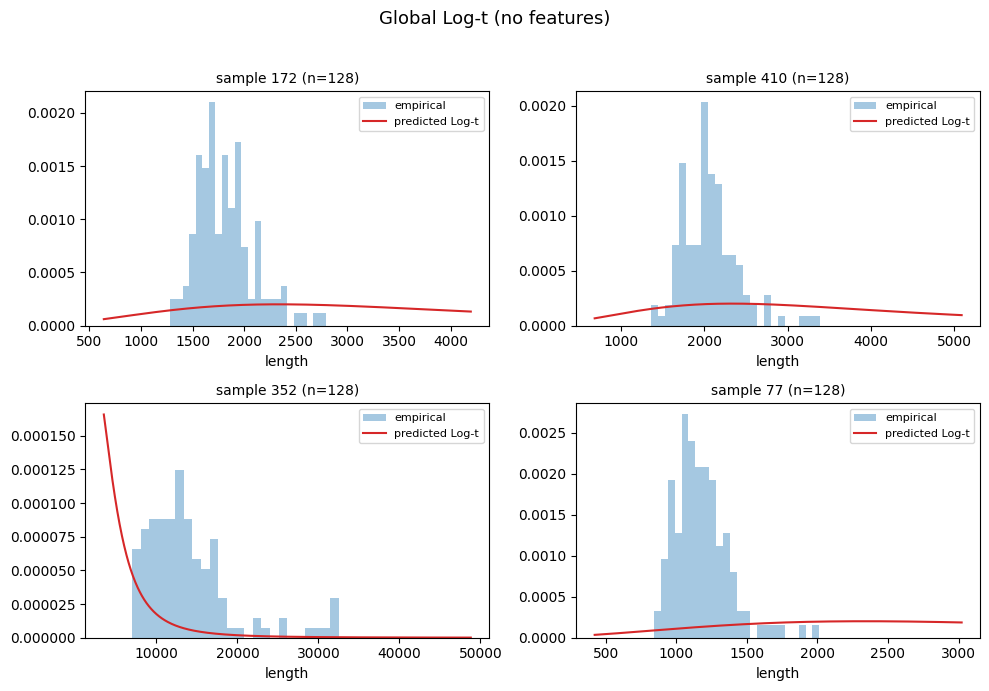

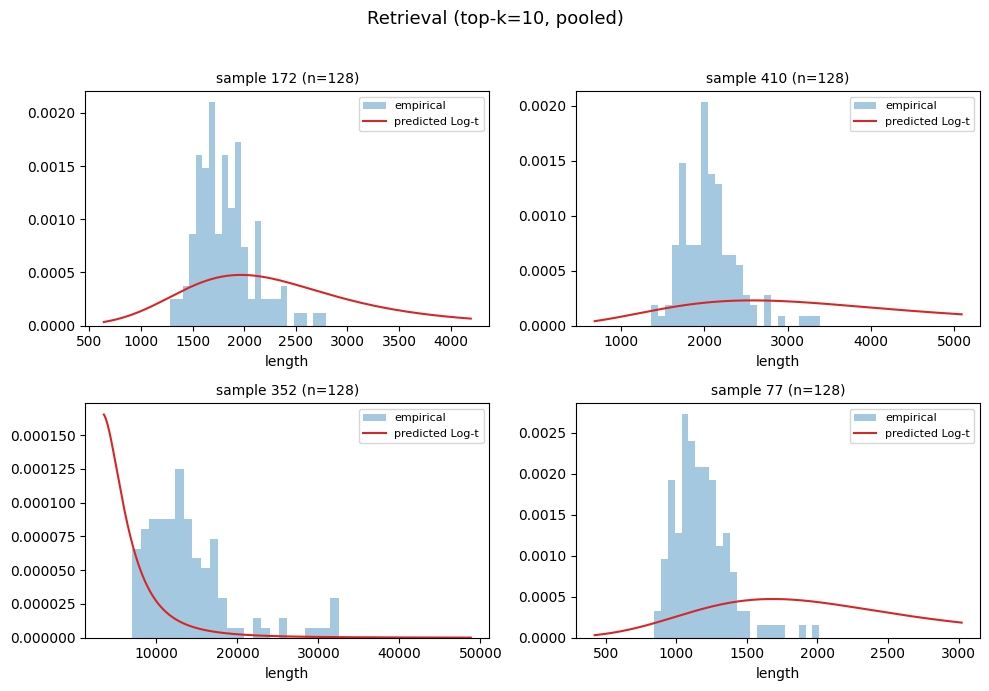

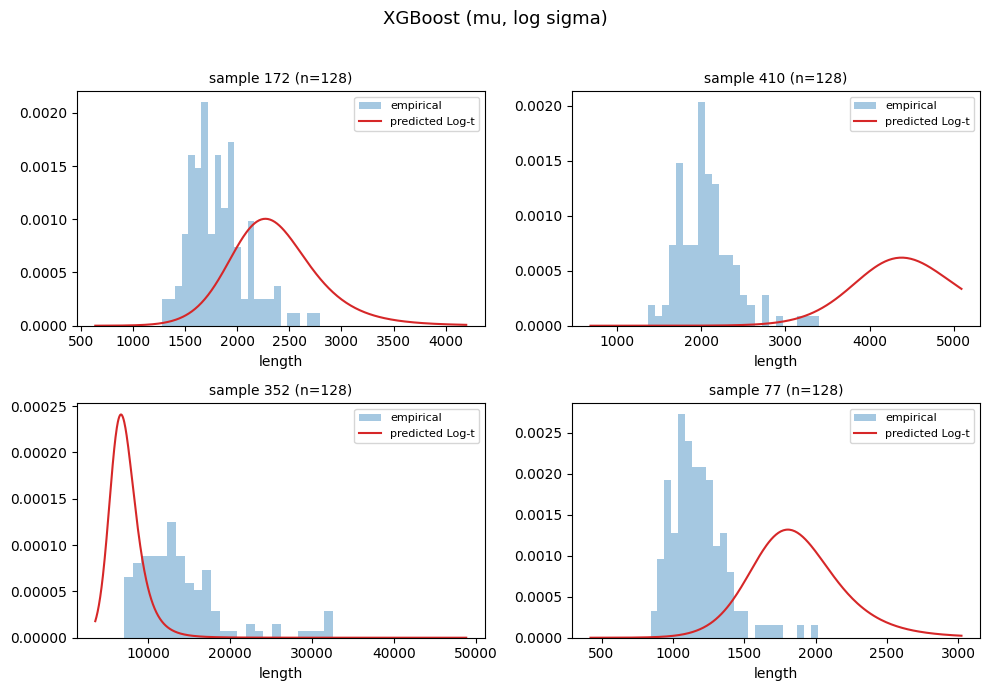

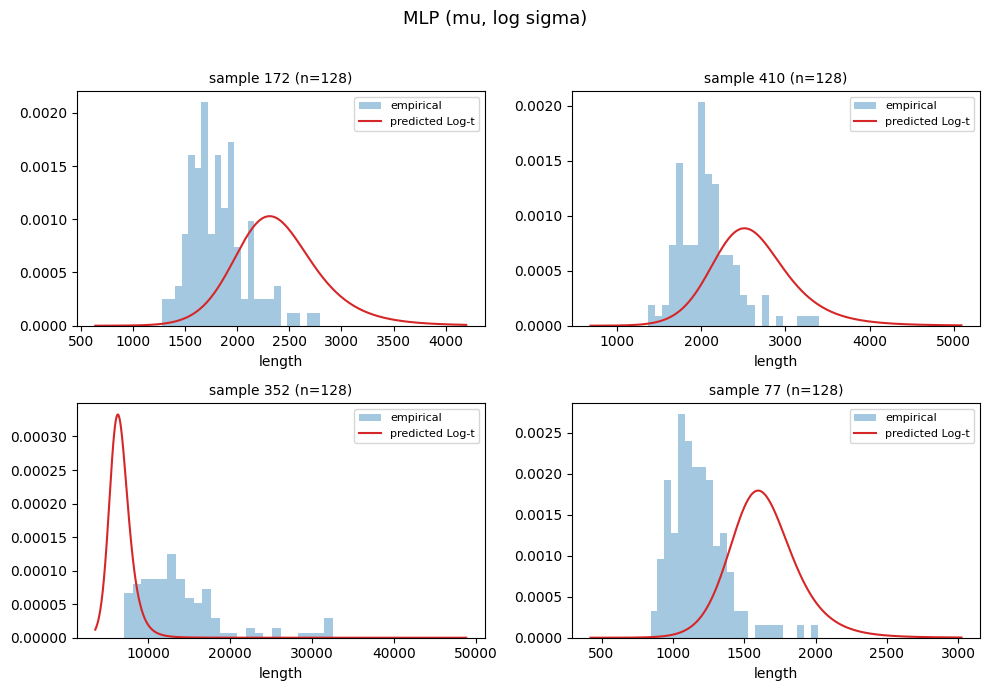

In [25]:
"""Cell 11 — Comparison table + qualitative plots (one figure per model)."""
table = pd.DataFrame(results).T[["NLL_logspace", "Wasserstein", "Tail_MAE"]]
print(table.round(4))

# Pick 4 test prompts once, reuse across all 4 figures
np.random.seed(SEED)
sel = np.random.choice(len(test_ids), 4, replace=False)

models_to_plot = {
    "Global Log-t (no features)": Yh_global,
    "Retrieval (top-k=10, pooled)": Yh_retr10,
    "XGBoost (mu, log sigma)":     Yh_xgb,
    "MLP (mu, log sigma)":         Yh_mlp,
}

def plot_model(title, Yh):
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))
    fig.suptitle(title, fontsize=13)
    for ax, i in zip(axes.flat, sel):
        sid = test_ids[i]
        L = test_lengths[sid]
        mu, sigma = float(Yh[i, 0]), float(np.exp(Yh[i, 1]))
        grid_log = np.linspace(np.log(L.min()*0.5+1), np.log(L.max()*1.5+1), 400)
        pdf_log = student_t.pdf(grid_log, df=NU_STAR, loc=mu, scale=sigma)
        grid = np.exp(grid_log)
        pdf_lin = pdf_log / grid  # change of variables: p_L(l) = p_logL(log l) / l
        ax.hist(L, bins=24, density=True, alpha=0.4, label="empirical")
        ax.plot(grid, pdf_lin, label="predicted Log-t", color="C3")
        ax.set_title(f"sample {sid} (n={len(L)})", fontsize=10)
        ax.set_xlabel("length"); ax.legend(fontsize=8)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

for title, Yh in models_to_plot.items():
    plot_model(title, Yh)


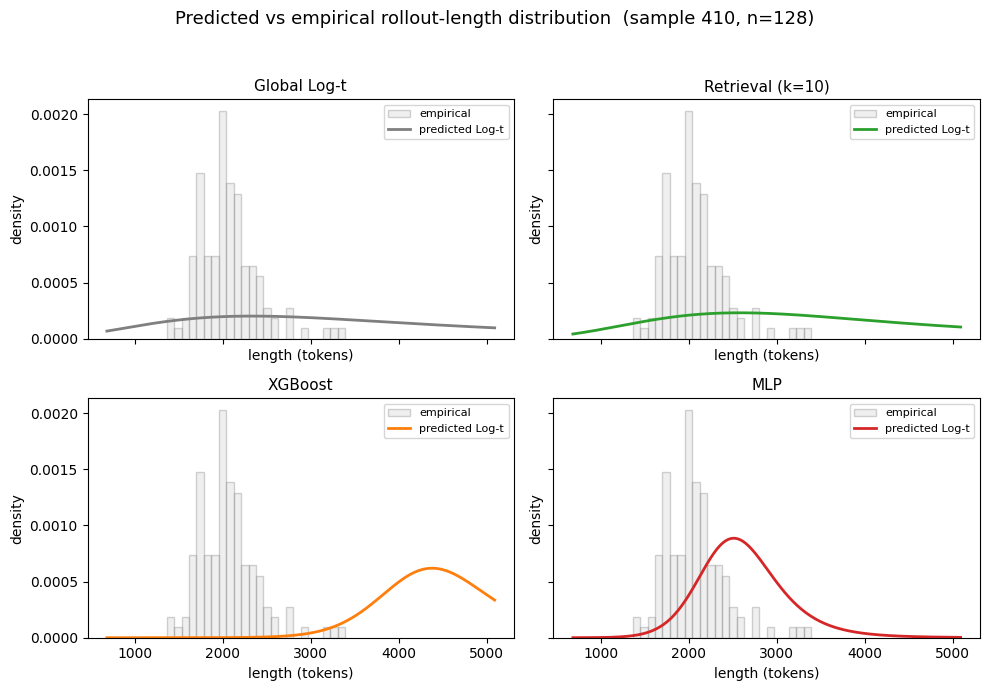

In [29]:
"""Cell 12 — Paper figure: 2x2 model comparison on a single test prompt."""
PROMPT_PICK = int(sel[1])  # change to any index in [0, 100) to swap prompt
sid = test_ids[PROMPT_PICK]
L = test_lengths[sid]

panels = [
    ("Global Log-t",            Yh_global,  "tab:gray"),
    ("Retrieval (k=10)",        Yh_retr10,  "tab:green"),
    ("XGBoost",                 Yh_xgb,     "tab:orange"),
    ("MLP",                     Yh_mlp,     "tab:red"),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
fig.suptitle(f"Predicted vs empirical rollout-length distribution  (sample {sid}, n={len(L)})",
             fontsize=13)

grid_log = np.linspace(np.log(L.min()*0.5+1), np.log(L.max()*1.5+1), 400)
grid = np.exp(grid_log)

for ax, (title, Yh, color) in zip(axes.flat, panels):
    mu, sigma = float(Yh[PROMPT_PICK, 0]), float(np.exp(Yh[PROMPT_PICK, 1]))
    pdf_lin = student_t.pdf(grid_log, df=NU_STAR, loc=mu, scale=sigma) / grid
    ax.hist(L, bins=24, density=True, alpha=0.35, color="lightgray",
            edgecolor="gray", label="empirical")
    ax.plot(grid, pdf_lin, color=color, lw=2.0, label="predicted Log-t")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("length (tokens)")
    ax.set_ylabel("density")
    ax.legend(fontsize=8, loc="upper right")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


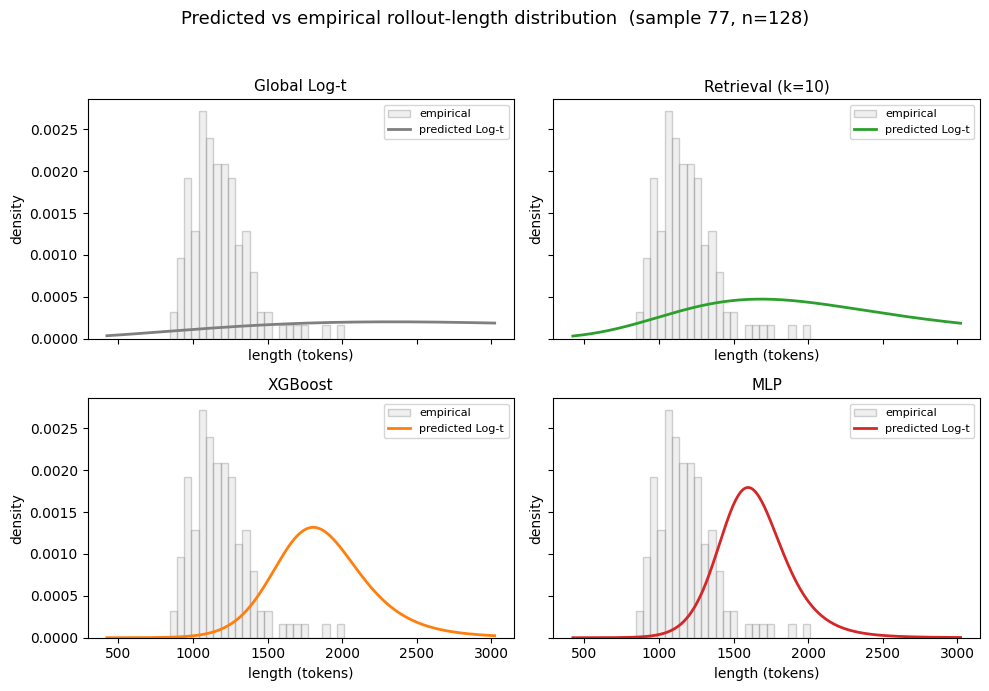

In [31]:
"""Cell 12 — Paper figure: 2x2 model comparison on a single test prompt."""
PROMPT_PICK = int(sel[3])  # change to any index in [0, 100) to swap prompt
sid = test_ids[PROMPT_PICK]
L = test_lengths[sid]

panels = [
    ("Global Log-t",            Yh_global,  "tab:gray"),
    ("Retrieval (k=10)",        Yh_retr10,  "tab:green"),
    ("XGBoost",                 Yh_xgb,     "tab:orange"),
    ("MLP",                     Yh_mlp,     "tab:red"),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
fig.suptitle(f"Predicted vs empirical rollout-length distribution  (sample {sid}, n={len(L)})",
             fontsize=13)

grid_log = np.linspace(np.log(L.min()*0.5+1), np.log(L.max()*1.5+1), 400)
grid = np.exp(grid_log)

for ax, (title, Yh, color) in zip(axes.flat, panels):
    mu, sigma = float(Yh[PROMPT_PICK, 0]), float(np.exp(Yh[PROMPT_PICK, 1]))
    pdf_lin = student_t.pdf(grid_log, df=NU_STAR, loc=mu, scale=sigma) / grid
    ax.hist(L, bins=24, density=True, alpha=0.35, color="lightgray",
            edgecolor="gray", label="empirical")
    ax.plot(grid, pdf_lin, color=color, lw=2.0, label="predicted Log-t")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("length (tokens)")
    ax.set_ylabel("density")
    ax.legend(fontsize=8, loc="upper right")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
